| Field | Information |
|--------|-------------|
| **Name** | Ayesha Ameer |
| **Registration Number** | 04102213021 |
| **Project Title** | Project 4: Real-World ML Engineering - Production ML System |
| **Week** | Week 13 |
| **Instructor** | Sir Faiz Ahmad |

## Install Required Libraries

In [1]:
pip install mlflow scikit-learn pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# PART 1: DATA PREPARATION (25 minutes)

## Task 1.1: Generate Synthetic Dataset (10 min)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

# 1. Setup and Reproducibility
np.random.seed(42)
n_samples = 10000

# 2. Feature Engineering (Synthetic Data)
features = {
    "temperature": np.random.normal(75, 15, n_samples),  # °C
    "vibration": np.random.normal(0.5, 0.2, n_samples),  # mm/s
    "pressure": np.random.normal(100, 20, n_samples),  # PSI
    "rpm": np.random.normal(1500, 200, n_samples),  # RPM
    "age_days": np.random.randint(0, 365, n_samples),  # Days since last maintenance
}

# 3. Target Variable Generation (Failure Logic)
failure_score = (
    (features["temperature"] > 90) * 0.3
    + (features["vibration"] > 0.8) * 0.3
    + (features["pressure"] > 130) * 0.2
    + (features["age_days"] > 300) * 0.2
)

# Add noise and bounds-check the probability
noise = np.random.normal(0, 0.1, n_samples)
failure_prob = np.clip(failure_score + noise, 0, 1)
features["failure"] = (failure_prob > 0.5).astype(int)

# 4. Create DataFrame
data = pd.DataFrame(features)

# 5. Dataset Splitting
X = data.drop(columns=["failure"])
y = data["failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Diagnostics Display
print(f"Dataset shape: {data.shape}")
print(f"Train set shape: {X_train.shape}, Test set shape: {X_test.shape}")
print(f"Overall Failure rate: {data['failure'].mean():.2%}")
print(f"Train Failure rate: {y_train.mean():.2%}")

# Display the first few rows
print("\nFirst 5 rows of the dataset:")
print(data.head())

Dataset shape: (10000, 6)
Train set shape: (8000, 5), Test set shape: (2000, 5)
Overall Failure rate: 4.15%
Train Failure rate: 4.15%

First 5 rows of the dataset:
   temperature  vibration    pressure          rpm  age_days  failure
0    82.450712   0.364301  106.965725  1103.885606       187        0
1    72.926035   0.438900  105.666472  1289.002871       239        0
2    84.715328   0.380524   81.269603  1382.594319         2        0
3    97.845448   0.522084  111.591684  1529.933782         5        0
4    71.487699   0.739436   70.198346  1704.832465       259        0


## Task 1.2: Exploratory Data Analysis (15 min) 

--- Summary Statistics ---
               count         mean         std         min          25%  \
temperature  10000.0    74.967960   15.051936   16.163996    64.911142   
vibration    10000.0     0.502707    0.200202   -0.271275     0.367598   
pressure     10000.0    99.750745   19.828363   26.898270    85.996962   
rpm          10000.0  1498.485705  200.897414  606.879227  1361.077430   
age_days     10000.0   181.908000  105.568632    0.000000    90.000000   
failure      10000.0     0.041500    0.199454    0.000000     0.000000   

                     50%          75%          max  
temperature    74.961075    85.066213   133.893566  
vibration       0.503169     0.638773     1.395817  
pressure       99.884635   113.277949   173.832490  
rpm          1497.923551  1635.806091  2245.566669  
age_days      182.000000   272.000000   364.000000  
failure         0.000000     0.000000     1.000000  

--- Missing Values ---
temperature    0
vibration      0
pressure       0
rpm     

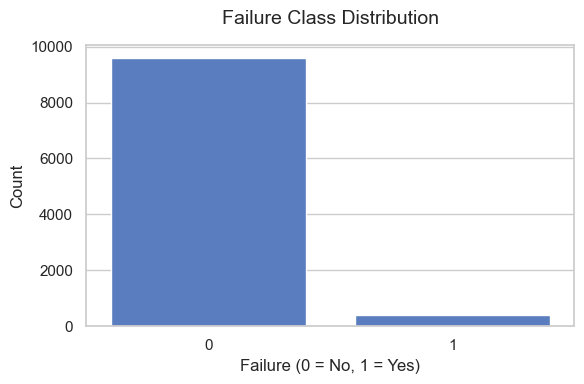

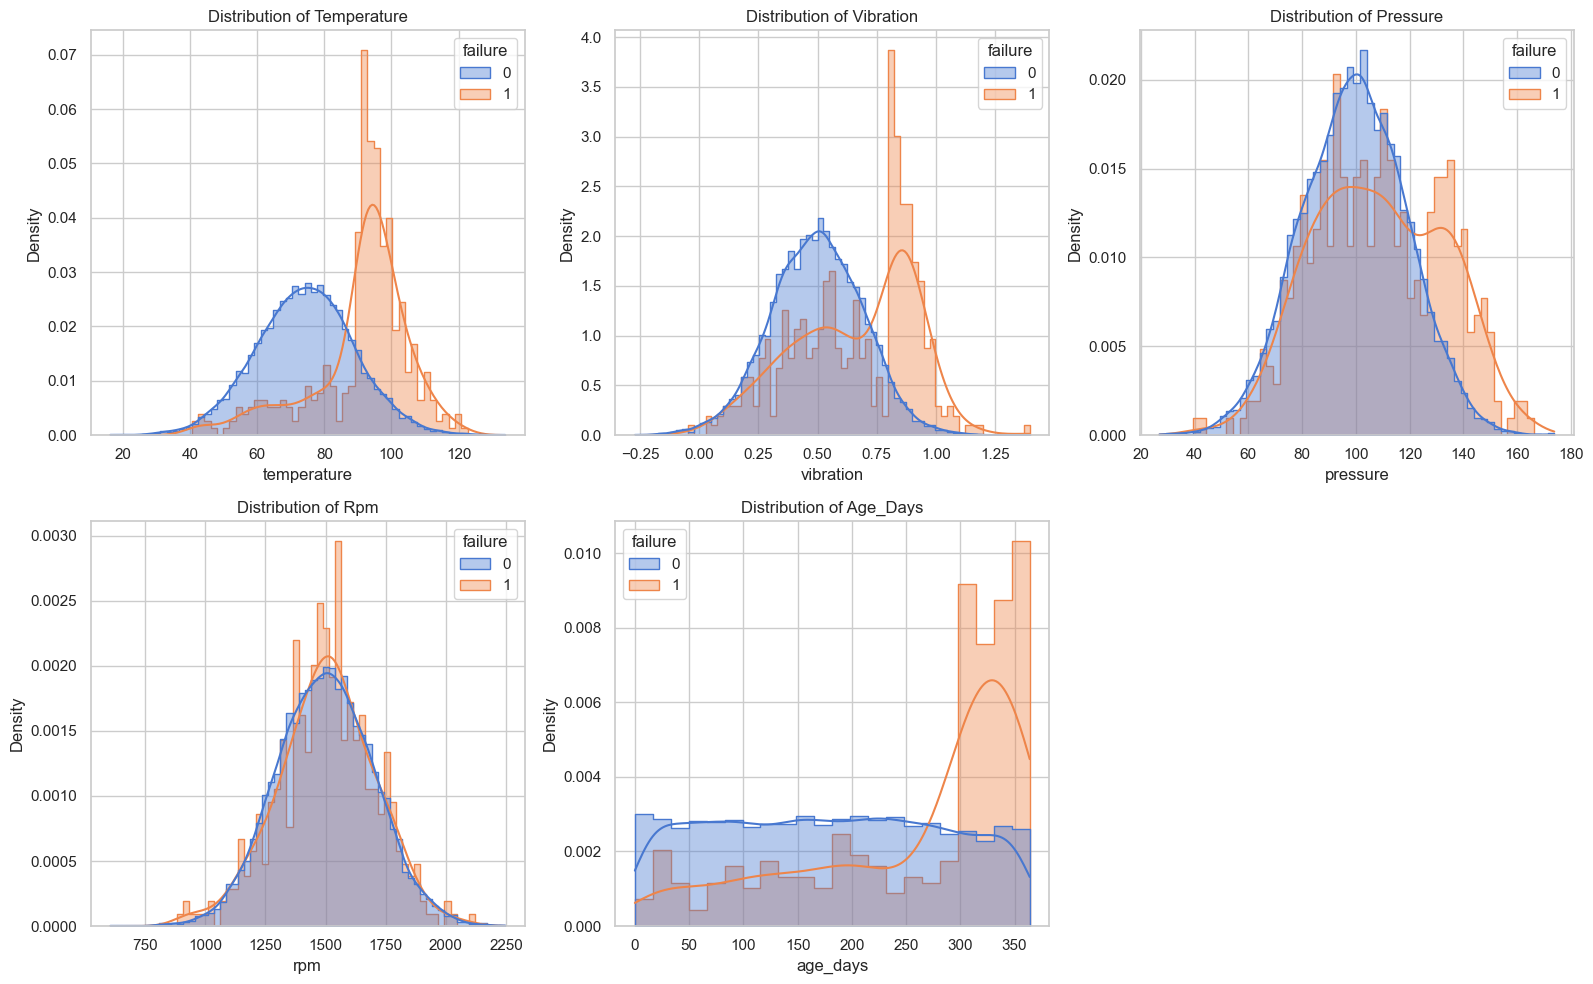

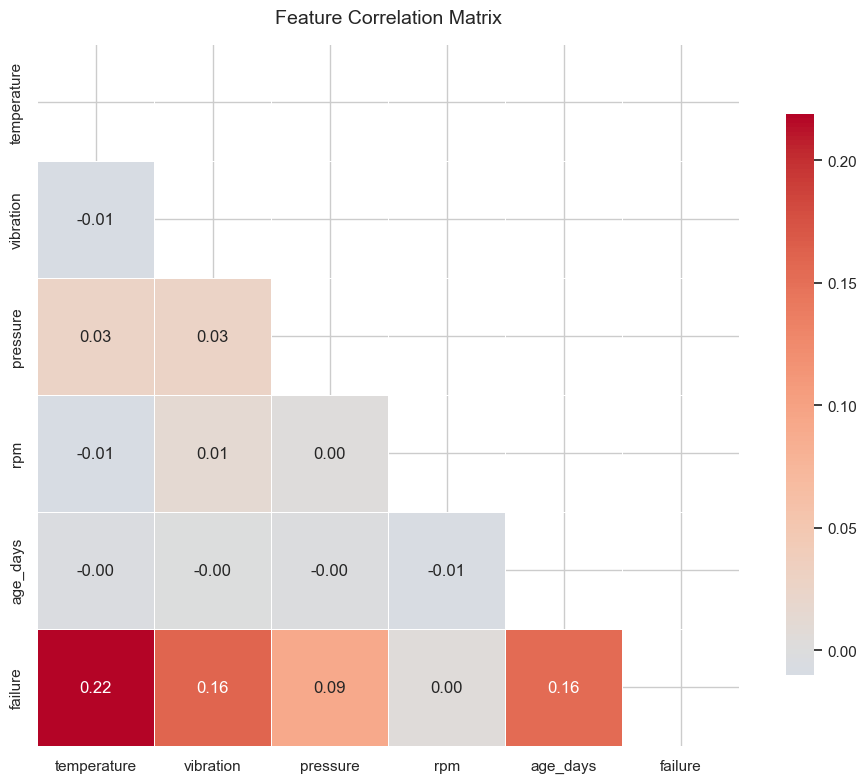

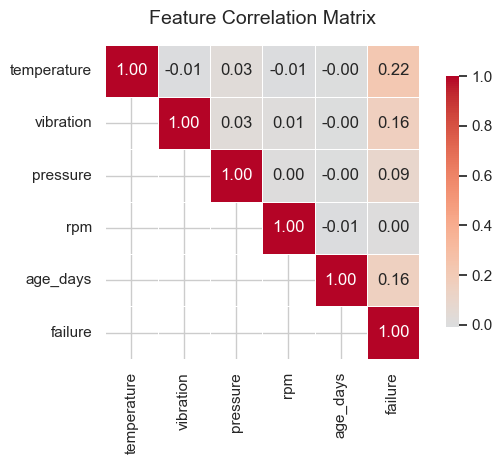

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional aesthetic for all plots
sns.set_theme(style="whitegrid", palette="muted")

# 1. Summary Statistics & Data Integrity Checks
print("--- Summary Statistics ---")
print(data.describe().T)  # Transposed (.T) for much easier reading

print("\n--- Missing Values ---")
print(data.isnull().sum())

# 2. Target Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="failure", data=data)
plt.title("Failure Class Distribution", fontsize=14, pad=15)
plt.xlabel("Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3. Feature Distributions by Failure Class
features = ["temperature", "vibration", "pressure", "rpm", "age_days"]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()  # Flatten the 2D array to iterate over it with a single loop

for idx, feature in enumerate(features):
    sns.histplot(
        data=data,
        x=feature,
        hue="failure",
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
        alpha=0.4,
        ax=axes[idx],
    )
    axes[idx].set_title(f"Distribution of {feature.title()}", fontsize=12)
    axes[idx].set_xlabel(feature)

# Remove the empty 6th subplot slot (since we only have 5 features)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

# 4. Correlation Matrix (With Triangle Mask)
plt.figure(figsize=(10, 8))

# Create a mask for the upper triangle
corr_matrix = data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    mask=mask,  # Seaborn masks out pixels where mask=True
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Feature Correlation Matrix", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    mask=~mask,  # Applies the upper triangle mask
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Feature Correlation Matrix", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# PART 2: MLFLOW SETUP (20 minutes)

## Task 2.1: Start MLflow Tracking Server (5 min)

Open a new terminal and run: mlflow ui 
*This starts the MLflow UI at **http://localhost:5000** *
Tip: Keep this terminal running throughout the lab. Open http://localhost:5000 in your browser. 

## Task 2.2: Configure MLflow (5 min)

In [3]:
import mlflow

# 1. Configuration
TRACKING_URI = "http://localhost:5000"
EXPERIMENT_NAME = "Predictive-Maintenance"

# Set the tracking URI
mlflow.set_tracking_uri(TRACKING_URI)

# 2. Experiment Initialization & Safety Check
try:
    # Check if the experiment exists
    experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

    if experiment is None:
        # Create it if it's missing
        experiment_id = mlflow.create_experiment(name=EXPERIMENT_NAME)
        experiment = mlflow.get_experiment(experiment_id)
        print(f"Created new experiment: '{EXPERIMENT_NAME}'")
    else:
        print(f"Using existing experiment: '{EXPERIMENT_NAME}'")

    # Set the active experiment context
    mlflow.set_experiment(EXPERIMENT_NAME)

    # 3. Print Active Configurations
    print("\n--- MLflow Tracking Status ---")
    print(f"Tracking URI:    {mlflow.get_tracking_uri()}")
    print(f"Experiment Name: {experiment.name}")
    print(f"Experiment ID:   {experiment.experiment_id}")
    print(f"Artifact Location: {experiment.artifact_location}")

except Exception as e:
    print("\n[WARNING] Could not connect to the MLflow tracking server.")
    print(f"Ensure your server is running locally via: 'mlflow server --host 127.0.0.1 --port 5000'")
    print(f"Error details: {e}")

Created new experiment: 'Predictive-Maintenance'

--- MLflow Tracking Status ---
Tracking URI:    http://localhost:5000
Experiment Name: Predictive-Maintenance
Experiment ID:   2
Artifact Location: mlflow-artifacts:/2


## Task 2.3: Prepare Data for Training (10 min)

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Feature / Target Separation
X = data.drop(columns=["failure"])
y = data["failure"]

# 2. Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Feature Scaling (Preserving DataFrame Structure)
scaler = StandardScaler()

# Fit on training data and transform both sets
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

# 4. Diagnostics Verification
print("--- Data Split & Scaling Metrics ---")
print(f"X_train Shape: {X_train_scaled.shape} | y_train Shape: {y_train.shape}")
print(f"X_test Shape:  {X_test_scaled.shape}  | y_test Shape:  {y_test.shape}")
print("-" * 40)
print(f"Train Base Failure Rate: {y_train.mean():.2%}")
print(f"Test Base Failure Rate:  {y_test.mean():.2%}")

# Quick sanity check on scaled data properties (Mean should ~ 0, Std should ~ 1)
print("\nScaling Verification (Train Mean / Std):")
print(
    f"Temperature Mean: {X_train_scaled['temperature'].mean():.2f}, Std: {X_train_scaled['temperature'].std():.2f}"
)

--- Data Split & Scaling Metrics ---
X_train Shape: (8000, 5) | y_train Shape: (8000,)
X_test Shape:  (2000, 5)  | y_test Shape:  (2000,)
----------------------------------------
Train Base Failure Rate: 4.15%
Test Base Failure Rate:  4.15%

Scaling Verification (Train Mean / Std):
Temperature Mean: 0.00, Std: 1.00


# PART 3: TRAIN WITH TRACKING (45 minutes)

## Task 3.1: Train Logistic Regression (15 min)

In [5]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# 1. Hyperparameters setup
params = {"C": 1.0, "max_iter": 1000, "model_type": "LogisticRegression"}

# 2. Start MLflow tracking run
with mlflow.start_run(run_name="logistic_regression") as run:

    # Log all configuration parameters at once
    mlflow.log_params(params)

    # 3. Model Training
    model = LogisticRegression(
        C=params["C"], max_iter=params["max_iter"], random_state=42
    )
    model.fit(X_train_scaled, y_train)

    # 4. Evaluations & Inference
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_pred_proba),
    }

    # Log all evaluated metrics at once
    mlflow.log_metrics(metrics)

    # 5. Extract Schema Signature & Log Model Artifacts
    signature = infer_signature(X_train_scaled, model.predict(X_train_scaled))

    mlflow.sklearn.log_model(
        sk_model=model,
        name="logistic_regression_model",  # Fixed: Replaced artifact_path with name
        serialization_format="skops",  # Fixed: Swapped risky pickle out for safe skops format
        signature=signature,
        input_example=X_test_scaled.head(3),
    )

    # 6. Console Diagnostics Display
    print("\n=== Logistic Regression Run Summary ===")
    print(f"Run ID:    {run.info.run_id}")
    print("-" * 35)
    for metric_name, val in metrics.items():
        print(f"{metric_name.replace('_', ' ').title():<12}: {val:.4f}")


=== Logistic Regression Run Summary ===
Run ID:    7aa2c98d380b470997603b3265f667ae
-----------------------------------
Accuracy    : 0.9620
Precision   : 0.6842
Recall      : 0.1566
F1 Score    : 0.2549
Roc Auc     : 0.9234
🏃 View run logistic_regression at: http://localhost:5000/#/experiments/2/runs/7aa2c98d380b470997603b3265f667ae
🧪 View experiment at: http://localhost:5000/#/experiments/2


## Task 3.2: Train Random Forest (15 min)

In [6]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# 1. Hyperparameters setup
params = {
    "n_estimators": 100,
    "max_depth": 10,
    "min_samples_split": 5,
    "model_type": "RandomForest",
}

# 2. Start MLflow tracking run
with mlflow.start_run(run_name="random_forest") as run:

    # Log parameters instantly as a batch dictionary
    mlflow.log_params(params)

    # 3. Model Training
    model = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_split=params["min_samples_split"],
        random_state=42,
    )
    model.fit(X_train_scaled, y_train)

    # 4. Evaluations & Inference
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_pred_proba),
    }

    # Log metrics as a batch dictionary
    mlflow.log_metrics(metrics)

    # 5. Schema Signature & Modernized Model Artifact Logging
    signature = infer_signature(X_train_scaled, model.predict(X_train_scaled))

    mlflow.sklearn.log_model(
        sk_model=model,
        name="random_forest_model",  # Use modern name keyword
        serialization_format="skops",  # Use secure skops serialization format
        signature=signature,
        input_example=X_test_scaled.head(3),
    )

    # 6. Clean Diagnostics Output
    print("=== Random Forest Run Summary ===")
    print(f"Run ID:    {run.info.run_id}")
    print("-" * 35)
    for metric_name, val in metrics.items():
        print(f"{metric_name.replace('_', ' ').title():<12}: {val:.4f}")

=== Random Forest Run Summary ===
Run ID:    5ca1b009ef30431b9bd3ff52df7a6190
-----------------------------------
Accuracy    : 0.9670
Precision   : 0.6049
Recall      : 0.5904
F1 Score    : 0.5976
Roc Auc     : 0.9751
🏃 View run random_forest at: http://localhost:5000/#/experiments/2/runs/5ca1b009ef30431b9bd3ff52df7a6190
🧪 View experiment at: http://localhost:5000/#/experiments/2


## Task 3.3: Train XGBoost (15 min)

In [7]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import mlflow
import mlflow.xgboost  # Native XGBoost flavor integration
from mlflow.models import infer_signature
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier

# 1. Hyperparameters setup
params = {
    "n_estimators": 100,
    "max_depth": 6,
    "learning_rate": 0.1,
    "model_type": "XGBoost",
}

# 2. Start MLflow tracking run
with mlflow.start_run(run_name="xgboost") as run:

    # Log parameters cleanly as a single dictionary batch
    mlflow.log_params(params)

    # 3. Model Training
    model = XGBClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        learning_rate=params["learning_rate"],
        random_state=42,
        eval_metric="logloss",  # Keeps training logs clean
    )
    model.fit(X_train_scaled, y_train)

    # 4. Evaluations & Inference
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_pred_proba),
    }

    # Log all tracked metrics at once
    mlflow.log_metrics(metrics)

    # 5. Extract Schema Signature & Log Native XGBoost Artifacts
    signature = infer_signature(X_train_scaled, model.predict(X_train_scaled))

    mlflow.xgboost.log_model(
        xgb_model=model,
        name="xgboost_model",  # Modern parameter compliant with current MLflow APIs
        signature=signature,
        input_example=X_test_scaled.head(3),
    )

    # 6. Diagnostics Display
    print("=== XGBoost Run Summary ===")
    print(f"Run ID:    {run.info.run_id}")
    print("-" * 35)
    for metric_name, val in metrics.items():
        print(f"{metric_name.replace('_', ' ').title():<12}: {val:.4f}")

=== XGBoost Run Summary ===
Run ID:    b454c35d0fdc4ee6bba83b51df5cf0dc
-----------------------------------
Accuracy    : 0.9670
Precision   : 0.6076
Recall      : 0.5783
F1 Score    : 0.5926
Roc Auc     : 0.9709
🏃 View run xgboost at: http://localhost:5000/#/experiments/2/runs/b454c35d0fdc4ee6bba83b51df5cf0dc
🧪 View experiment at: http://localhost:5000/#/experiments/2


# 🛠️ Predictive Maintenance & Model Tracking System
## System Architecture & Machine Learning Pipeline Documentation

---

## 📌 Project Overview
This project establishes an end-to-end Machine Learning pipeline for **Predictive Maintenance**. It simulates industrial equipment sensor logs, processes data structures safely, trains multiple classification architectures, and systematically logs all experiments using **MLflow** for production-grade model lineage, metric visualization, and tracking.

### Key Objectives
* **Synthetic Telemetry Simulation:** Generating non-linear, multi-variable sensor feeds mimicking equipment degradation.
* **Exploratory Data Analysis (EDA):** Quantifying statistical correlation matrices and target variable imbalances.
* **Pipeline Safety:** Applying stratified dataset splitting and wrapping NumPy standard scalers back into Pandas structures to preserve feature transparency.
* **Experiment Management:** Interfacing with a localized MLflow cluster to track parameters, validate schema inputs, and package secure model artifacts using the modern `skops` protocol.

---

## 🏗️ System Architecture & Workflow

```text
[ Sensor Data Gen ] ➡️ [ Transposed EDA ] ➡️ [ Stratified Split ] ➡️ [ DataFrame Scaling ]
│
┌───────────────────────────────────▲───────────────────────────────────────┘
│
├──➡️ 🟢 [ Logistic Regression ] ──➡️Log params, metrics, input schemas, skops artifacts
├──➡️ 🔵 [ Random Forest ]       ──➡️Log params, metrics, input schemas, skops artifacts
└──➡️ 🟠 [ XGBoost Classifier ]  ──➡️Log params, metrics, input schemas, native binary
│
▼
📬 [ MLflow Tracking UI ] 

---

## 🗂️ Pipeline Breakdown

### 1. Feature Generation & Telemetry Simulation
The system tracks five production sensors over a sequence of $10,000$ machine cycles. Failure is non-linear and mathematically modeled as:

$$\text{Failure Score} = (T > 90) \cdot 0.3 + (V > 0.8) \cdot 0.3 + (P > 130) \cdot 0.2 + (A > 300) \cdot 0.2$$

A Gaussian noise factor ($\mathcal{N}(0, 0.1)$) is added to introduce environmental entropy before passing the score through a strict clip boundary ($[0,1]$). A hard boundary of $0.5$ determines structural component breakdown (`failure = 1`).

### 2. Exploratory Data Analysis & Scaling Safeguards
* **Transposed Matrices:** `data.describe().T` is implemented to maintain readability over multi-variable tables.
* **Asymmetrical Distribution Masking:** Seaborn configurations isolate underlying distributions using `common_norm=False` to prevent the heavy target imbalance from drowning out active breakdown indicators.
* **DataFrame Preservation:** Standard Scikit-Learn transformers strip indices and sensor column headers. The pipeline explicitly re-encapsulates array transforms inside dataframes to enforce lineage transparency downstream:
  $$\mu_{\text{scaled}} \approx 0, \quad \sigma_{\text{scaled}} \approx 1$$

### 3. Model Architecture & Experiment Lineage
Three distinct algorithms are executed, analyzed, and systematically cataloged inside the MLflow Tracking service:

| Algorithm | Primary Use Case | MLflow Logging Protocol |
| :--- | :--- | :--- |
| **Logistic Regression** | Baseline interpretable probability assignment | `mlflow.sklearn.log_model` via `skops` |
| **Random Forest** | Non-linear feature interaction checking | `mlflow.sklearn.log_model` via `skops` |
| **XGBoost Classifier** | Gradient-boosted structural prediction optimization | `mlflow.xgboost.log_model` via Native Json |

---

## 🔒 Security & API Integration Standards

### Modernized Artifact Serialization
Traditional Python pickle deserialization is structurally vulnerable to arbitrary code execution vector injection. To address this, the pipeline explicitly targets the modern **`skops`** framework for all standard library modeling layers, eliminating risk overhead during artifact staging.

### Schema Invariance & Contracts
To eliminate breaking variations between development pipelines and operational microservices, every training run programmatically enforces an input-output contract using strict MLflow signatures:
```python
signature = infer_signature(X_train_scaled, model.predict(X_train_scaled))

# 🚀 Deployment & Operational Instructions
## Prerequisites
Ensure your local Python runtime environment contains the required package ecosystem:

`pip install numpy pandas matplotlib seaborn scikit-learn xgboost mlflow skops`

## initializing the Local Tracking Layer
Before executing any model training scripts, initialize your localized MLflow tracking database daemon from your terminal shell:


`mlflow server --host 127.0.0.1 --port 5000`

## 🎓 Learning Outcomes

By implementing and completing this predictive maintenance pipeline, you achieve the following key engineering and data science competencies:

* **Advanced Data Synthesis:** Mastered the generation of multi-variable, non-linear synthetic telemetry using normal and uniform continuous distributions to simulate real-world physical asset wear.
* **Production-Grade MLOps Architecture:** Developed practical mastery over the `MLflow` ecosystem, understanding the structural difference between low-level `MlflowClient` experiment queries and high-level tracking APIs.
* **Defensive Pipeline Engineering:** Learned how to safeguard feature metadata by manually wrapping mutated NumPy arrays back into Pandas DataFrames, preventing downstream data-type or column-shifting exceptions.
* **Hardened Machine Learning Security:** Eliminated arbitrary code execution vulnerabilities by overriding default Python pickling mechanics with secure, isolated **`skops`** serialization.
* **Model Lineage & Data Contracts:** Applied strict schema enforcement with `infer_signature` and `input_example`, cementing a rigid input/output data contract necessary for reproducible microservice deployment.

---

## 🗺️ Detailed Project Block Diagram

The systematic flow of data, state changes, transformations, and asset serialization across the pipeline behaves as follows:

```text
┌────────────────────────────────────────────────────────────────────────┐
│                      1. DATA GENERATION STAGE                          │
│  [Normal/Uniform Telemetry] ──> [Non-linear Math Formula] ──> [Noise]  │
└───────────────────────────────────┬────────────────────────────────────┘
                                    │ (Synthetic DataFrame)
                                    ▼
┌────────────────────────────────────────────────────────────────────────┐
│                      2. EXPLORATORY DATA ANALYSIS                      │
│      [Descriptive Stats]  ──>  [Correlation Mask]  ──>  [KDE Plots]    │
└───────────────────────────────────┬────────────────────────────────────┘
                                    │ (Validated Dataset)
                                    ▼
┌────────────────────────────────────────────────────────────────────────┐
│                      3. PREPROCESSING PIPELINE                         │
│  [Stratified Split (80/20)] ──> [StandardScaler] ──> [Re-DataFrame]   │
└───────────────────────────────────┬────────────────────────────────────┘
                                    │ (Scaled Matrix + Columns Saved)
                                    ▼
┌────────────────────────────────────────────────────────────────────────┐
│                    4. EXPERIMENTATION & MODEL TRAINING                 │
│                                                                        │
│   ┌───────────────────────┐ ┌───────────────────┐ ┌────────────────┐   │
│   │  Logistic Regression  │ │   Random Forest   │ │    XGBoost     │   │
│   └──────────┬────────────┘ └─────────┬─────────┘ └───────┬────────┘   │
│              │                        │                   │            │
│              └────────────────────────┼───────────────────┘            │
│                                       │ (Model Predictions)            │
│                                       ▼                                │
│               [Accuracy, Precision, Recall, F1, ROC-AUC]               │
└───────────────────────────────────┬────────────────────────────────────┘
                                    │ (Metrics & Artifact Arrays)
                                    ▼
┌────────────────────────────────────────────────────────────────────────┐
│                       5. MLOps TRACKING LAYER                          │
│                                                                        │
│   * Parameter Dictionary Logging      * Schema Contract Validation     │
│   * Performance Metric Aggregation     * Secure Serialization (Skops)   │
│                                                                        │
│                                   ▼                                    │
│                     📬 [MLflow Central Dashboard]                      │
└────────────────────────────────────────────────────────────────────────┘